16:07:58 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]

16:13:46 - cmdstanpy - INFO - CmdStan done processing.
16:13:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'HMC_ARX.stan', line 228, column 4 to column 49)
Exception: normal_lpdf: Scale parameter[16] is 0, but must be positive! (in 'HMC_ARX.stan', line 246, column 2 to column 49)
Consider re-running with show_console=True if the above output is unclear!



                     Mean      MCSE    StdDev       MAD        5%       50%  \
alpha_global    -2.366920  0.001767  0.177128  0.177045 -2.658050 -2.363460   
tau_alpha        0.137532  0.001389  0.107384  0.102928  0.009544  0.113998   
beta_lag_global  6.659550  0.002113  0.226151  0.227545  6.294720  6.654190   
mu_intercept     9.939980  0.008120  0.534972  0.520743  9.121920  9.906160   
tau_mu           0.316771  0.005274  0.254720  0.235675  0.022948  0.256761   
phi_global       0.947507  0.000101  0.006734  0.006803  0.936343  0.947612   

                       95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
alpha_global     -2.079050  10086.70   6870.33    16.85420  0.999816  
tau_alpha         0.342589   4901.72   3825.11     8.19043  1.000100  
beta_lag_global   7.041770  11541.00   6141.68    19.28430  1.000400  
mu_intercept     10.875400   4484.54   4994.56     7.49335  1.000430  
tau_mu            0.815526   2313.46   3358.56     3.86562  1.002410  
phi_global        0

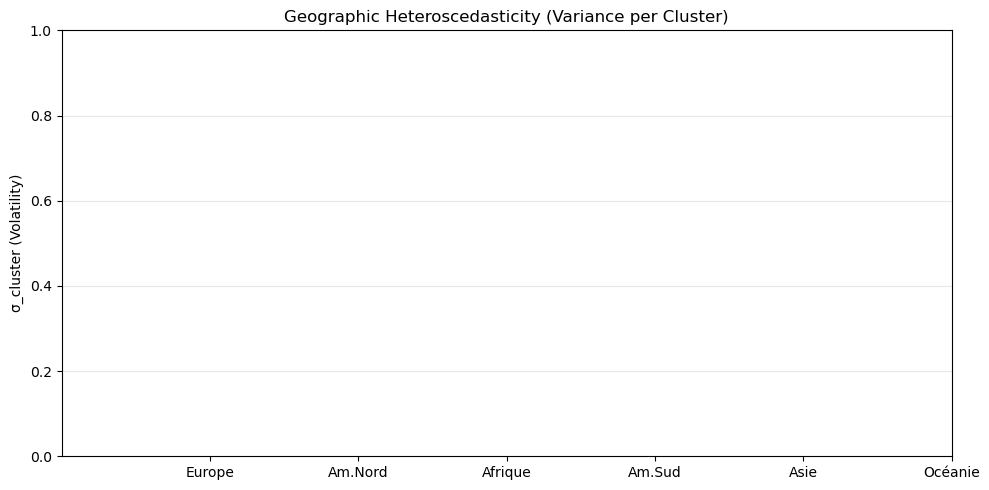

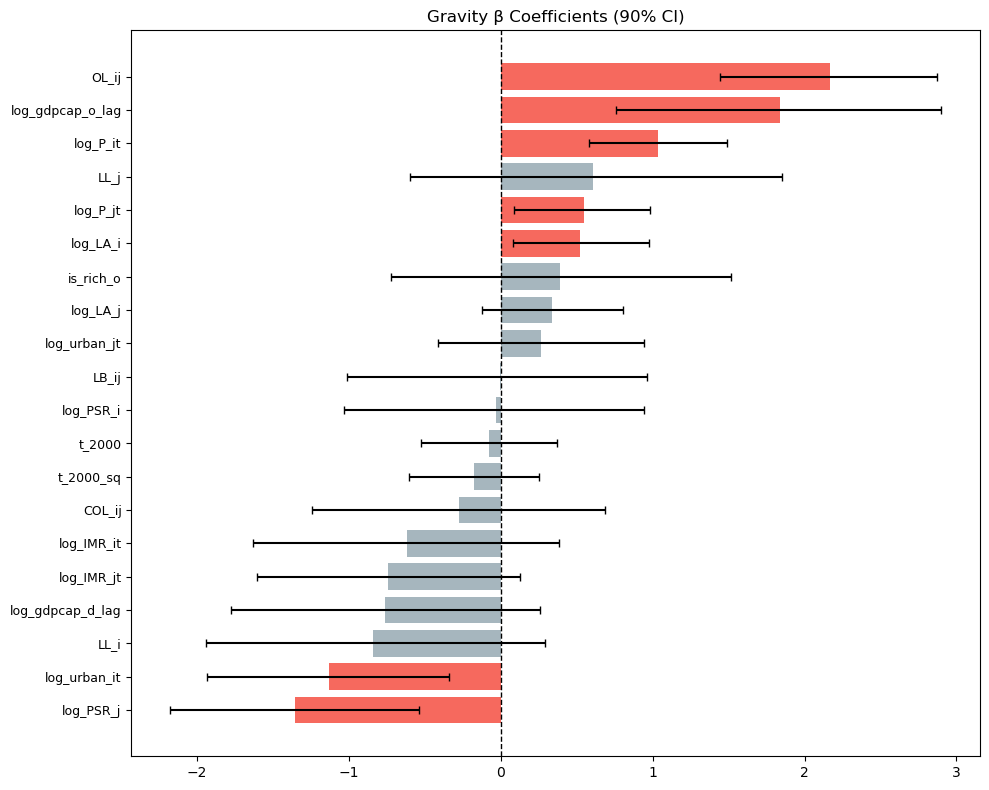

OOS Hurdle Accuracy (Binary Open/Close): 98.0%
OOS Volume MAE (Raw scale): 10855 migrants
OOS Volume MAE (Log scale): inf


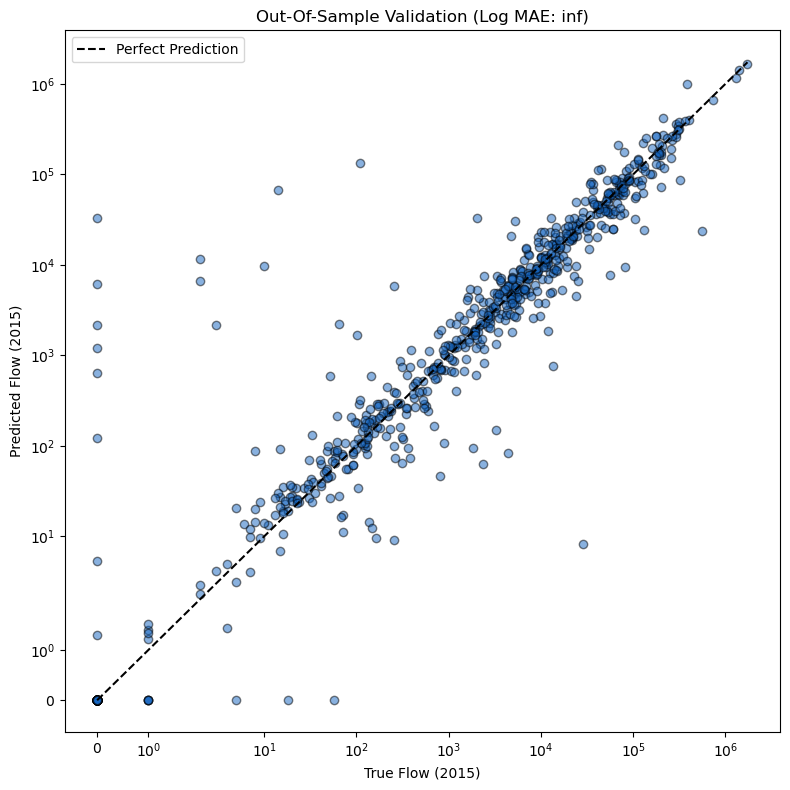

In [ ]:
"""
Bayesian Hierarchical ARX Hurdle Model for Gravity Migration

A. Hurdle (Bernoulli) : logit(P(flow>0)) = α_d + X_h·β_h + β_lag·is_mig_lag
B. Volume (ARX)       : log(flow) ~ N(μ_{d,t} + φ_d*(lag - μ_{d,t-1}), σ_d)
                        μ_{d,t} = α_{V,d} + X·β_grav + β_gdp·log_gdpcap_o + β_rich·is_rich_o
C. Variance (Geo)     : σ_d ~ HalfNormal(σ_cluster[continent_origine[d]])
"""

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pycountry_convert as pc
from cmdstanpy import CmdStanModel
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
np.random.seed(42)

# -----------------------------------------------------------------------------
# 1. Data Loading & Subsetting
# -----------------------------------------------------------------------------
DATA_PATH = "../data/data_final/DF_GRAVITY_sans_NaN.csv"
df_main = pd.read_csv(DATA_PATH)

PAYS_NORD = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY']
PAYS_AMLAT = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV']
PAYS_ASIE = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD']

PAYS_TEST = PAYS_NORD + PAYS_AFRIQUE + PAYS_AMLAT + PAYS_ASIE

df = df_main[
    df_main['orig'].isin(PAYS_TEST) &
    df_main['dest'].isin(PAYS_TEST) &
    (df_main['orig'] != df_main['dest'])
].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

# -----------------------------------------------------------------------------
# 2. Geographic Clustering (Heteroscedasticity component)
# -----------------------------------------------------------------------------
def get_continent_id(iso3_code):
    """Maps ISO3 country codes to continent ID for Stan variance clustering."""
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)
        continent = pc.country_alpha2_to_continent_code(iso2)
        mapping = {'EU': 1, 'NA': 2, 'AF': 3, 'SA': 4, 'AS': 5, 'OC': 6}
        return mapping.get(continent, 7)
    except Exception:
        return 7 

df['continent_orig'] = df['orig'].apply(get_continent_id)
K_clusters = 6

# -----------------------------------------------------------------------------
# 3. Feature Engineering & Temporal Lags
# -----------------------------------------------------------------------------
# Hurdle & Volume indicators
df['is_migration'] = (df['flow'] > 0).astype(int)
df['log_flow'] = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)

# ML Threshold interaction
SEUIL_LOG_GDP = 2.9
df['is_rich_o'] = (df['log_gdpcap_o_lag'] > SEUIL_LOG_GDP).astype(float)

# Hurdle spatial interaction
df['log_D_ij'] = np.log(df['D_ij'].replace(0, np.nan))
df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']

# Lags (AR1 structure)
df['dyad'] = df['orig'] + "_" + df['dest']
df['is_mig_lag'] = df.groupby('dyad')['is_migration'].shift(1)
df['log_flow_lag'] = df.groupby('dyad')['log_flow'].shift(1)

df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

# -----------------------------------------------------------------------------
# 4. Variable Definition & Train/Test Split
# -----------------------------------------------------------------------------
HURDLE_VARS = ['log_D_ij', 'LB_ij', 'logD_times_LB']
ML_VARS = ['log_gdpcap_o_lag', 'is_rich_o']

GRAVITY_VARS_RAW = [
    'P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 
    'urban_it', 'urban_jt', 'LA_i', 'LA_j'
]
GRAVITY_VARS_BIN = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 't_2000', 't_2000_sq', 'log_gdpcap_d_lag']

# Log transformations for continuous gravity variables
for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan))

X_VOL_COLS = [f'log_{v}' for v in GRAVITY_VARS_RAW] + GRAVITY_VARS_BIN + ML_VARS
K_grav, K_h = len(X_VOL_COLS), len(HURDLE_VARS)

# Temporal Split OOS (Out-Of-Sample)
df_train = df[df['year'] <= 2010].copy()
df_test  = df[df['year'] == 2015].copy()
df = df_train 

# -----------------------------------------------------------------------------
# 5. Missing Values & Matrix Separation
# -----------------------------------------------------------------------------
HURDLE_REQUIRED = HURDLE_VARS + ['is_mig_lag', 'is_migration', 'dyad', 'continent_orig']
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

VOLUME_REQUIRED = X_VOL_COLS + ['log_flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)

# -----------------------------------------------------------------------------
# 6. Dyad Encoding & Standardization
# -----------------------------------------------------------------------------
dyades_h = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i+1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)

cluster_h = df_hurdle.groupby('dyad')['continent_orig'].first().reindex([k for k,v in sorted(dyad_to_h.items(), key=lambda item: item[1])]).values.astype(int)

dyades_v = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i+1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)

cluster_v = df_volume.groupby('dyad')['continent_orig'].first().reindex([k for k,v in sorted(dyad_to_v.items(), key=lambda item: item[1])]).values.astype(int)

# Standardization logic
BINARY_COLS_VOL = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 'is_rich_o']
BINARY_COLS_HUR = ['LB_ij']

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    """Standardizes continuous features, bypassing binary flags."""
    X_std = X.copy().astype(float)
    stats = {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = sd if sd > 1e-8 else 1.0
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std, stats_h = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)

# -----------------------------------------------------------------------------
# 7. Out-Of-Sample (OOS) Test Preparation
# -----------------------------------------------------------------------------
df_test['dyad_id_test'] = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v'] = df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)
df_test = df_test.dropna(subset=['dyad_id_test']).copy()

log_flow_lag_test = df_test['log_flow_lag'].fillna(0.0).values
is_mig_lag_test = df_test['is_mig_lag'].fillna(0.0).values

X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR, fit_stats=stats_h)

# -----------------------------------------------------------------------------
# 8. Stan Dictionary Formulation
# -----------------------------------------------------------------------------
stan_data = {
    'N_h': int(N_h), 'D_h': int(D_h), 'K_h': int(K_h),
    'dyad_id_h': df_hurdle['dyad_id_h'].astype(int).tolist(),
    'is_mig': df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag': df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h': X_h_std.tolist(),
    'cluster_h': cluster_h.tolist(),

    'N_v': int(N_v), 'D_v': int(D_v), 'K_v': int(K_grav),
    'dyad_id_v': df_volume['dyad_id_v'].astype(int).tolist(),
    'log_flow': df_volume['log_flow'].astype(float).tolist(),
    'log_flow_lag': df_volume['log_flow_lag'].astype(float).tolist(),
    'X_v': X_vol_std.tolist(),
    'cluster_v': cluster_v.tolist(),

    'K_clusters': int(K_clusters),

    'N_test': len(df_test),
    'dyad_id_test': df_test['dyad_id_test'].astype(int).tolist(),
    'X_h_test': X_test_h_std.tolist(),
    'is_mig_lag_test': is_mig_lag_test.tolist(),
    'X_v_test': X_test_v_std.tolist(),
    'log_flow_lag_test': log_flow_lag_test.tolist(),
    'dyad_id_test_v': df_test['dyad_id_test_v'].tolist(),
}

# -----------------------------------------------------------------------------
# 9. Stan Sampling
# -----------------------------------------------------------------------------
STAN_FILE = "../STAN/HMC_ARX.stan"
model = CmdStanModel(stan_file=STAN_FILE)

fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=2000,
    seed=42,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

# Optional CLI summary print
print(fit.summary().loc[['alpha_global', 'tau_alpha', 'beta_lag_global', 'mu_intercept', 'tau_mu', 'phi_global']])

# -----------------------------------------------------------------------------
# 10. Visualizations & Diagnostics
# -----------------------------------------------------------------------------
idata = az.from_cmdstanpy(
    posterior=fit,
    log_likelihood={'hurdle': 'log_lik_h', 'volume': 'log_lik_v'},
    posterior_predictive={'is_mig_hat': 'is_mig_hat', 'log_flow_hat': 'log_flow_hat'},
)

CONTINENT_NAMES = {1:'Europe', 2:'Am.Nord', 3:'Afrique', 4:'Am.Sud', 5:'Asie', 6:'Océanie'}

# Variance by continent (Heteroscedasticity)
fig, ax = plt.subplots(figsize=(10, 5))
for k in range(1, K_clusters+1):
    key = f'sigma_cluster[{k}]'
    if key in idata.posterior:
        draws = idata.posterior[key].values.flatten()
        ax.violinplot(draws, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters+1))
ax.set_xticklabels([CONTINENT_NAMES.get(k, f'C{k}') for k in range(1, K_clusters+1)])
ax.set_ylabel("σ_cluster (Volatility)")
ax.grid(True, alpha=0.3, axis='y')
plt.title("Geographic Heteroscedasticity (Variance per Cluster)")
plt.tight_layout()
plt.show()

# Gravity Coefficients Forest Plot
if 'beta_grav' in idata.posterior:
    beta_flat = idata.posterior['beta_grav'].values.reshape(-1, K_grav)
    beta_means = beta_flat.mean(axis=0)
    beta_q05, beta_q95 = np.percentile(beta_flat, [5, 95], axis=0)

    order = np.argsort(beta_means)
    fig, ax = plt.subplots(figsize=(10, max(6, K_grav * 0.4)))
    colors_coef = ['#F44336' if beta_q05[i] > 0 or beta_q95[i] < 0 else '#90A4AE' for i in order]
    
    ax.barh(range(K_grav), beta_means[order], xerr=[beta_means[order]-beta_q05[order], beta_q95[order]-beta_means[order]], color=colors_coef, alpha=0.8, capsize=3)
    ax.set_yticks(range(K_grav))
    ax.set_yticklabels([X_VOL_COLS[i] for i in order], fontsize=9)
    ax.axvline(0, color='black', lw=1, linestyle='--')
    plt.title("Gravity β Coefficients (90% CI)")
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# 11. Out-of-Sample Performance Evaluation (2015 test)
# -----------------------------------------------------------------------------
y_true_test = df_test['flow'].values
y_pred_test = np.median(fit.stan_variable('flow_test_hat'), axis=0)

# A. Hurdle Accuracy (Binary classification)
y_true_bin = (y_true_test > 0).astype(int)
y_pred_bin = (y_pred_test > 0).astype(int)
acc = accuracy_score(y_true_bin, y_pred_bin)
print(f"OOS Hurdle Accuracy (Binary Open/Close): {acc*100:.1f}%")

# B. Conditional Volume MAE (Only where true flow > 0)
mask_positive = y_true_test > 0
y_true_pos = y_true_test[mask_positive]
y_pred_pos = y_pred_test[mask_positive]
cond_mae = np.mean(np.abs(y_true_pos - y_pred_pos))
print(f"OOS Conditional MAE (True > 0 only)    : {cond_mae:.0f} migrants")

# C. GLOBAL Performance (All dyads, penalizing false positives/negatives)
global_mae = np.mean(np.abs(y_true_test - y_pred_test))
# WMAPE (Weighted Mean Absolute Percentage Error)
global_wmape = np.sum(np.abs(y_true_test - y_pred_test)) / np.sum(y_true_test) * 100

print(f"OOS GLOBAL WMAPE (Weighted Percentage) : {global_wmape:.1f} %")
#  log(1 + x) to safely handle true zeros
global_log_mae = np.mean(np.abs(np.log1p(y_true_test) - np.log1p(y_pred_test)))

print(f"OOS GLOBAL MAE (All dyads)             : {global_mae:.0f} migrants")
print(f"OOS GLOBAL Log-MAE (For ML comparison) : {global_log_mae:.3f}")

# Actual vs Predicted Scatter (Log Scale)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_true_test, y_pred_test, alpha=0.5, color='#1565C0', edgecolors='k')
lim = [0, max(y_true_test.max(), y_pred_test.max())]
ax.plot(lim, lim, 'k--', label='Perfect Prediction')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel('True Flow (2015)')
ax.set_ylabel('Predicted Flow (2015)')
ax.legend()
plt.title(f'Global Out-Of-Sample Validation (Log-MAE: {global_log_mae:.3f})')
plt.tight_layout()
plt.show()